In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader.data as web

            BAA10Y
DATE              
2010-01-01     NaN
2010-01-04    2.54
2010-01-05    2.53
2010-01-06    2.49
2010-01-07    2.48


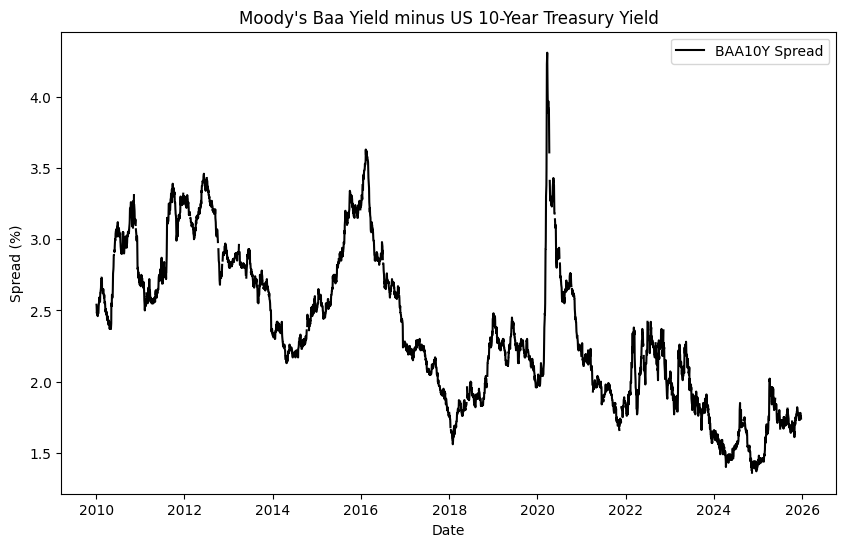

In [37]:
start = "2010-01-01"
end   = "2025-12-31"

# Descargar datos desde FRED
df = web.DataReader('BAA10Y', 'fred', start, end)

# Mostrar primeros datos
print(df.head())

# Graficar
plt.figure(figsize=(10,6))
plt.plot(df.index, df['BAA10Y'], label="BAA10Y Spread", color="black")
plt.title("Moody's Baa Yield minus US 10-Year Treasury Yield")
plt.ylabel("Spread (%)")
plt.xlabel("Date")
plt.grid(False)
plt.legend()
plt.savefig("baa10y_spread.png", dpi=300)
plt.show()

In [40]:
df = df.dropna()
y = df['BAA10Y'].values


In [31]:
def fourier_approximation(y, n_cycles):
    """
    Aproximación de Fourier con n_cycles
    """
    # Validar entrada
    if np.any(np.isnan(y)):
        raise ValueError("El array de entrada contiene NaNs")
    
    N = len(y)
    
    # Limitar n_cycles para evitar solapamiento
    n_cycles = min(n_cycles, N // 2)
    
    fft = np.fft.fft(y)
    fft_filtered = np.zeros_like(fft)

    # Mantener solo bajas frecuencias (DC + n_cycles armónicos)
    fft_filtered[:n_cycles + 1] = fft[:n_cycles + 1]
    
    # Solo copiar frecuencias negativas si no hay solapamiento
    if n_cycles > 0:
        fft_filtered[-n_cycles:] = fft[-n_cycles:]

    return np.real(np.fft.ifft(fft_filtered))

In [32]:
constant = np.mean(y)

fourier_1 = fourier_approximation(y, 1)
fourier_2 = fourier_approximation(y, 2)
fourier_3 = fourier_approximation(y, 3)
fourier_4 = fourier_approximation(y, 4)

In [35]:
fourier_10 = fourier_approximation(y, 10)

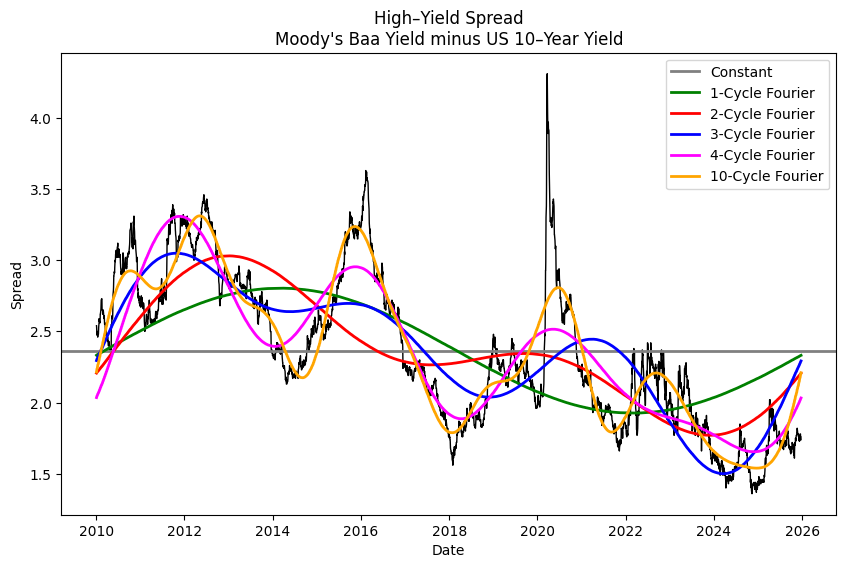

In [41]:
plt.figure(figsize=(10, 6))

# Serie original
plt.plot(df.index, df["BAA10Y"], color="black", linewidth=1)

# Constante
plt.axhline(constant, color="gray", linewidth=2, label="Constant")

# Fourier
plt.plot(df.index, fourier_1, color="green", linewidth=2, label="1-Cycle Fourier")
plt.plot(df.index, fourier_2, color="red", linewidth=2, label="2-Cycle Fourier")
plt.plot(df.index, fourier_3, color="blue", linewidth=2, label="3-Cycle Fourier")
plt.plot(df.index, fourier_4, color="magenta", linewidth=2, label="4-Cycle Fourier")
plt.plot(df.index, fourier_10, color="orange", linewidth=2, label="10-Cycle Fourier")

plt.title("High–Yield Spread\nMoody's Baa Yield minus US 10–Year Yield")
plt.xlabel("Date")
plt.ylabel("Spread")
plt.legend()
plt.grid(False)
plt.savefig("baa10y_spread.png", dpi=300)
plt.show()